# Gender-Based Violence in Nepal (2019-2026) - EDA

## Section 0: Setup & Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
%matplotlib inline

print("pandas:", pd.__version__)
print("numpy:", np.__version__)

pandas: 3.0.3
numpy: 2.4.6


In [3]:
df = pd.read_csv("../data/raw/GenderBasedVoilence2019-2026 Nepal.csv")
df['Date'] = pd.to_datetime(df['Date'], format = '%m/%d/%Y')

print("Shape:", df.shape)
df.head()

Shape: (42337, 11)


,Date,Fiscal_Year,Province_No,Province,District,Police_Station,Crime_Category,Victim_Demographic,Cases_Reported,Status,Year
0,2019-01-01,2018/19,1,Koshi,Morang,Urlabari PS,Rape,Woman,6,Under Investigation,2019
1,2019-01-01,2018/19,1,Koshi,Sunsari,WCSC Inaruwa,Rape,Girl-Child,4,Decided,2019
2,2019-01-01,2018/19,1,Koshi,Jhapa,WCSC Birtamod,Rape,Woman,2,Decided,2019
3,2019-01-01,2018/19,1,Koshi,Dhankuta,Dhankuta Sadar PS,Rape,Woman,1,Under Investigation,2019
4,2019-01-01,2018/19,1,Koshi,Sankhuwasabha,WCSC Khandbari,Rape,Girl-Child,5,Decided,2019


## Section 1: Data Overview & Quality Check

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 42337 entries, 0 to 42336
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                42337 non-null  datetime64[us]
 1   Fiscal_Year         42337 non-null  str           
 2   Province_No         42337 non-null  int64         
 3   Province            42337 non-null  str           
 4   District            42337 non-null  str           
 5   Police_Station      42337 non-null  str           
 6   Crime_Category      42337 non-null  str           
 7   Victim_Demographic  42337 non-null  str           
 8   Cases_Reported      42337 non-null  int64         
 9   Status              42337 non-null  str           
 10  Year                42337 non-null  int64         
dtypes: datetime64[us](1), int64(3), str(7)
memory usage: 3.6 MB


In [5]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
Date                  0
Fiscal_Year           0
Province_No           0
Province              0
District              0
Police_Station        0
Crime_Category        0
Victim_Demographic    0
Cases_Reported        0
Status                0
Year                  0
dtype: int64

Duplicate rows: 0


We can see that there are no missing values in any columns, and no rows are duplicated.

In [6]:
categorical_cols = ['Fiscal_Year', 'Province', 'District', 'Police_Station', 'Crime_Category', 'Victim_Demographic', 'Status']

for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values")

Fiscal_Year: 8 unique values
Province: 7 unique values
District: 76 unique values
Police_Station: 178 unique values
Crime_Category: 9 unique values
Victim_Demographic: 3 unique values
Status: 3 unique values


In [7]:
print("Crime categories:\n", df['Crime_Category'].unique(), "\n")
print("Victim demographics:\n", df['Victim_Demographic'].unique(), "\n")
print("Status values:\n", df['Status'].unique())

Crime categories:
 <StringArray>
[              'Rape',    'Attempt to Rape', 'Child Sexual Abuse',
  'Domestic Violence',  'Human Trafficking',     'Child Marriage',
         'Cybercrime',  'Sexual Harassment',     'Physical Abuse']
Length: 9, dtype: str 

Victim demographics:
 <StringArray>
['Woman', 'Girl-Child', 'Boy-Child']
Length: 3, dtype: str 

Status values:
 <StringArray>
['Under Investigation', 'Decided', 'Filed']
Length: 3, dtype: str


In [8]:
print("Date range:", df['Date'].min(), "to", df['Date'].max())
print("\nRows per year:")
print(df.groupby('Year').size())

Date range: 2019-01-01 00:00:00 to 2026-03-01 00:00:00

Rows per year:
Year
2019    5883
2020    5279
2021    5704
2022    5868
2023    5719
2024    6158
2025    6199
2026    1527
dtype: int64


**Note:** 2026 is a partial year in this dataset (containing data through March 2026 only). It will be excluded from year;y trend comparisions unless explicitly annotated.

In [9]:
df['Cases_Reported'].describe()

count    42337.000000
mean         4.009046
std          9.294793
min          0.000000
25%          0.000000
50%          1.000000
75%          3.000000
max        109.000000
Name: Cases_Reported, dtype: float64

In [10]:
zero_count = (df['Cases_Reported'] == 0).sum()
zero_pct = (df['Cases_Reported'] == 0).mean() * 100
print(f"Zero-case rows: {zero_count} out of {len(df)} ({zero_pct:.1f}%)")

Zero-case rows: 14583 out of 42337 (34.4%)


## Section 2: Trend Over Time

Note: 2026 is excluded from yearly comparisions below sinve it's a partial year.

In [11]:
yearly = df[df['Year'] != 2026].groupby('Year')['Cases_Reported'].sum()
yearly.head()

Year
2019    23277
2020    16973
2021    21668
2022    23832
2023    22982
Name: Cases_Reported, dtype: int64

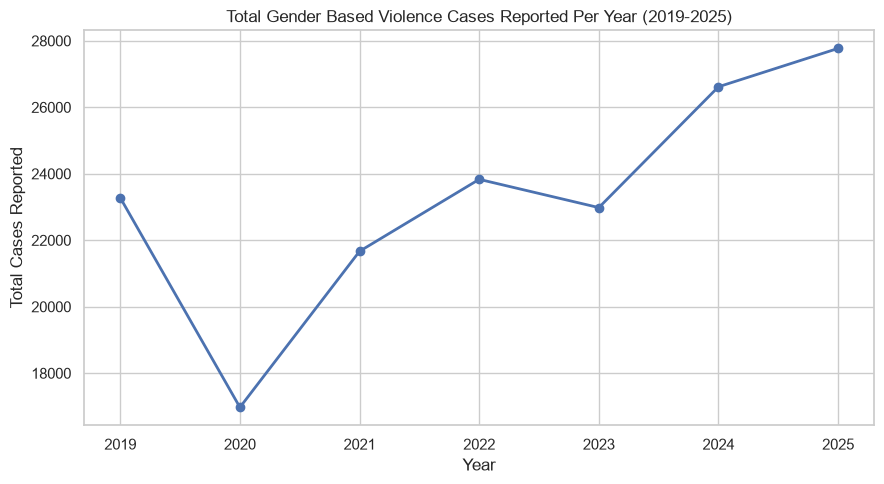

In [12]:
plt.figure(figsize = (9,5))
plt.plot(yearly.index, yearly.values, marker='o', linewidth = 2)
plt.title('Total Gender Based Violence Cases Reported Per Year (2019-2025)')
plt.xlabel('Year')
plt.ylabel('Total Cases Reported')

plt.xticks(yearly.index)
plt.tight_layout()
plt.savefig('../outputs/figures/yearly_totals.png', dpi=150)
plt.show()

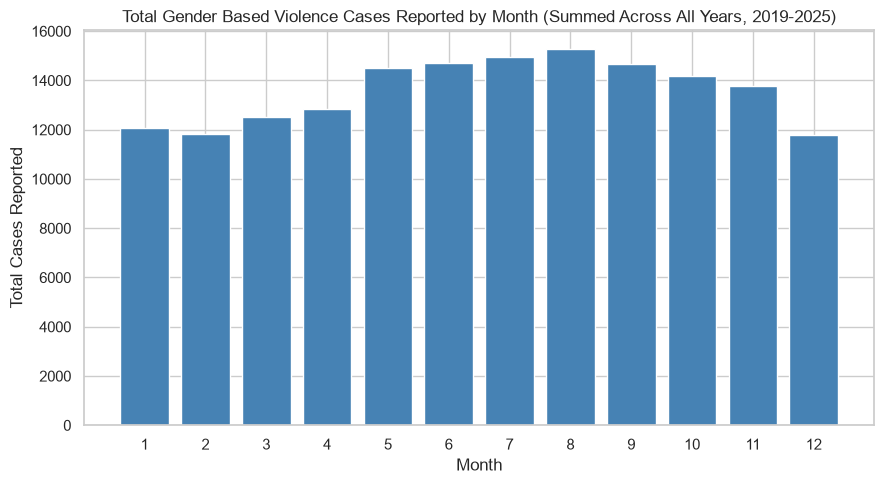

In [13]:
df['Month'] = df['Date'].dt.month

monthly_avg = df[df['Year'] != 2026].groupby('Month')['Cases_Reported'].sum()
monthly_avg

plt.figure(figsize = (9,5))
plt.bar(monthly_avg.index, monthly_avg.values, color='steelblue')
plt.title('Total Gender Based Violence Cases Reported by Month (Summed Across All Years, 2019-2025)')
plt.xlabel('Month')
plt.ylabel('Total Cases Reported')
plt.xticks(range(1,13))
plt.tight_layout()
plt.savefig('../outputs/figures/monthly_pattern.png')
plt.show()

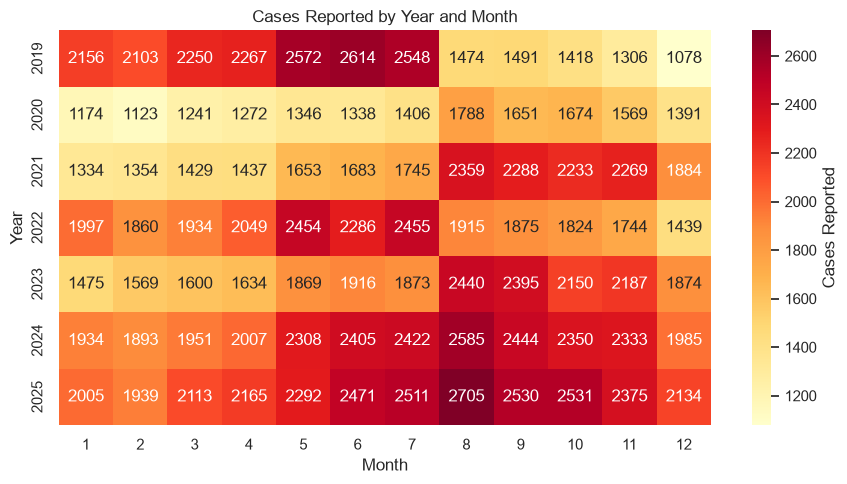

In [14]:
pivot = df[df['Year'] != 2026].pivot_table(
    index='Year', columns = 'Month', values = 'Cases_Reported', aggfunc='sum'
)

plt.figure(figsize = (9,5))
sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt='.0f', cbar_kws={'label': 'Cases Reported'})
plt.title('Cases Reported by Year and Month')
plt.xlabel('Month')
plt.ylabel('Year')
plt.tight_layout()
plt.savefig('../outputs/figures/year_month_heatmap.png', dpi=150)
plt.show()

**Observation:**

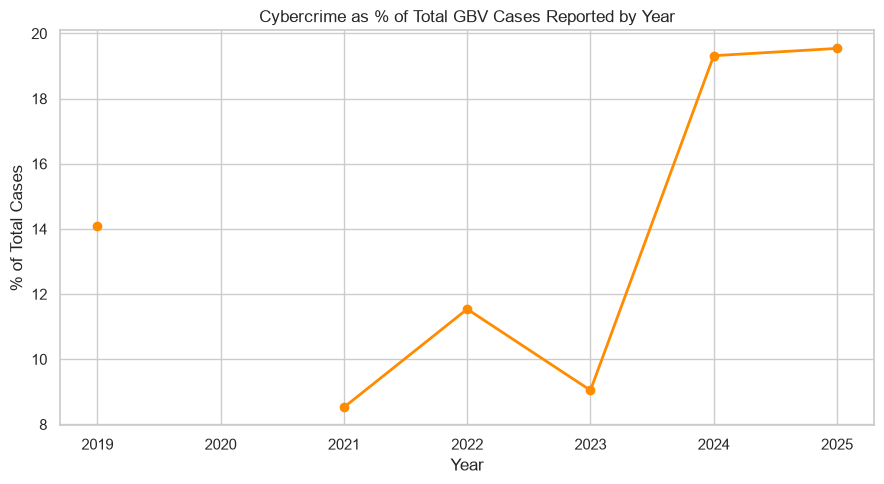

In [15]:
category_by_year = df[df['Year'] != 2026].groupby(['Year', 'Crime_Category'])['Cases_Reported'].sum().unstack()
cybercrime_share = (category_by_year['Cybercrime'] / category_by_year.sum(axis=1)) * 100

plt.figure(figsize = (9,5))
plt.plot(cybercrime_share.index, cybercrime_share.values, marker='o', color='darkorange', linewidth = 2)
plt.title('Cybercrime as % of Total GBV Cases Reported by Year')
plt.xlabel('Year')
plt.ylabel('% of Total Cases')
plt.xticks(cybercrime_share.index)
plt.tight_layout()
plt.savefig('../outputs/figures/cybercrime_share.png', dpi=150)
plt.show()

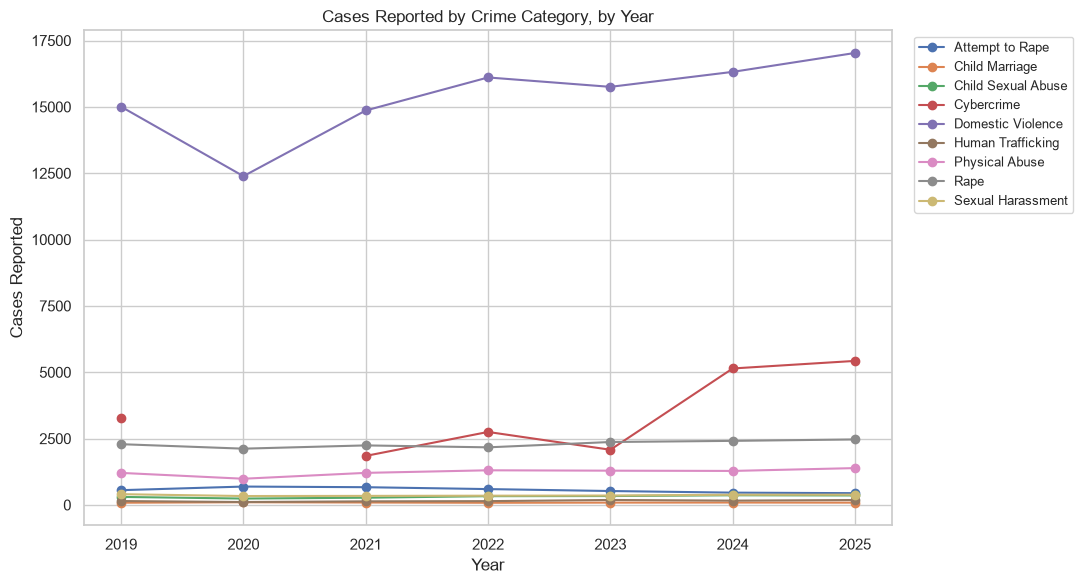

In [16]:
plt.figure(figsize = (11,6))

category_by_year

for category in category_by_year.columns:
    plt.plot(category_by_year.index, category_by_year[category], marker='o', label = category)

plt.title('Cases Reported by Crime Category, by Year')
plt.xlabel('Year')
plt.ylabel('Cases Reported')
plt.legend(bbox_to_anchor=(1.02,1), loc='upper left', fontsize=9)
plt.xticks(category_by_year.index)
plt.tight_layout()
plt.savefig('../outputs/figures/category_trends.png', dpi=150)
plt.show()

### Section 2 Takeaways

- **Overall trend:** Total cases dropped sharply in 2020 (~17000, down from ~23,300 in 2019), then climbed to a series high of ~27,800 by 2025. Since Domestic Violence dominates case volume, this overall pattern is largely driven by Domestic Violence trends specifically.

- **Seasonality:** Reporting is generally lower in winter (Jan/Feb/Dec) and higher in summer (May/Jun/Jul/Aug). This pattern holds across most of the 7 years. This could reflect genuine seasonal patterns in violence, or reporting administrative cycles (e.g./ mid July is Nepal's fiscal year-end) - the data alone can't distinguish between these.

- **Covid-19 period (2020):** The heatmap shows the decline in GBV reporting in 2020 was not limited to the lockdown months (which began ~March 2020). Jan-Mar 2020 was already lower than the same months in neighbouring years. Case counts stayed relatively lower through all of 2020 and into 2021. This suggests an overall decline in GBV reporting in 2020 (for reasons we are not certain of) rather than a decline in reporting due to the lockdown.

- **Cybercrime growth:** Cybercrime's share of total cases nearly doubled from ~9-12% (2021-2023) to ~19-19.5% (2024-2025). No cybercrime rows exist for 2020 in this dataset (likely a reporting gap for this category rather than an actual absence of cybercrime that year). This is also shown as a gap in the Cybercrime Share and Category Trends charts.

- **Category dominance:** Domestic Violence is the largest category every year by a wide margin. All categories besides Domestic Violence and Cybercrime remain relatively flat and low across the full period. Cybercrime is the category that's rising at the most rapid rate.

## Section 3: Geographic Patterns

**Note:** 2026 is excldued from totals below (partial year). All 7 provinces and 76 districts are included.

In [17]:
province_totals = df[df['Year'] != 2026].groupby('Province')['Cases_Reported'].sum().sort_values(ascending=False)
province_totals

Province
Bagmati          52112
Madhesh          39636
Lumbini          24810
Koshi            17146
Sudurpashchim    11667
Gandaki           9173
Karnali           8576
Name: Cases_Reported, dtype: int64

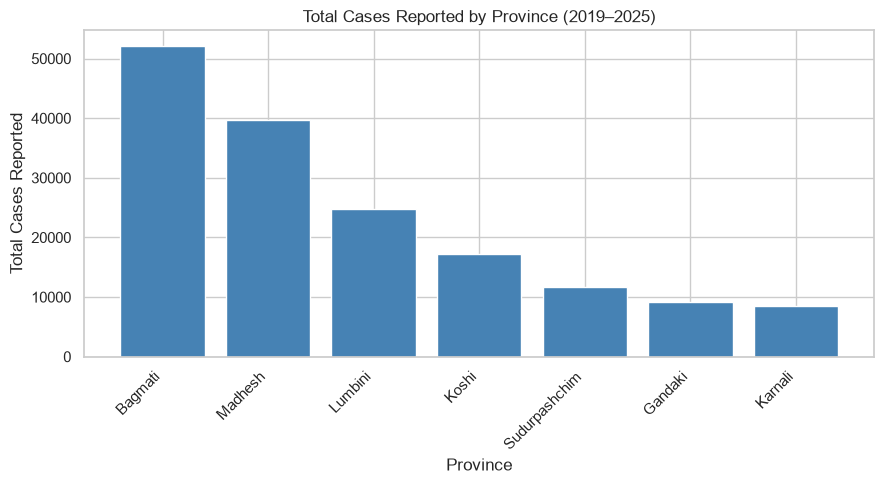

In [18]:
plt.figure(figsize=(9, 5))
plt.bar(province_totals.index, province_totals.values, color='steelblue')
plt.title('Total Cases Reported by Province (2019–2025)')
plt.xlabel('Province')
plt.ylabel('Total Cases Reported')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../outputs/figures/province_totals.png', dpi=150)
plt.show()

In [19]:
district_totals = df[df['Year'] != 2026].groupby('District')['Cases_Reported'].sum().sort_values(ascending=False)
district_totals

District
Kathmandu    11539
Bara          6604
Parsa         6533
Lalitpur      5843
Chitwan       4594
             ...  
Tanahu         785
Nawalpur       780
Gorkha         774
Lamjung        762
Syangja        746
Name: Cases_Reported, Length: 76, dtype: int64

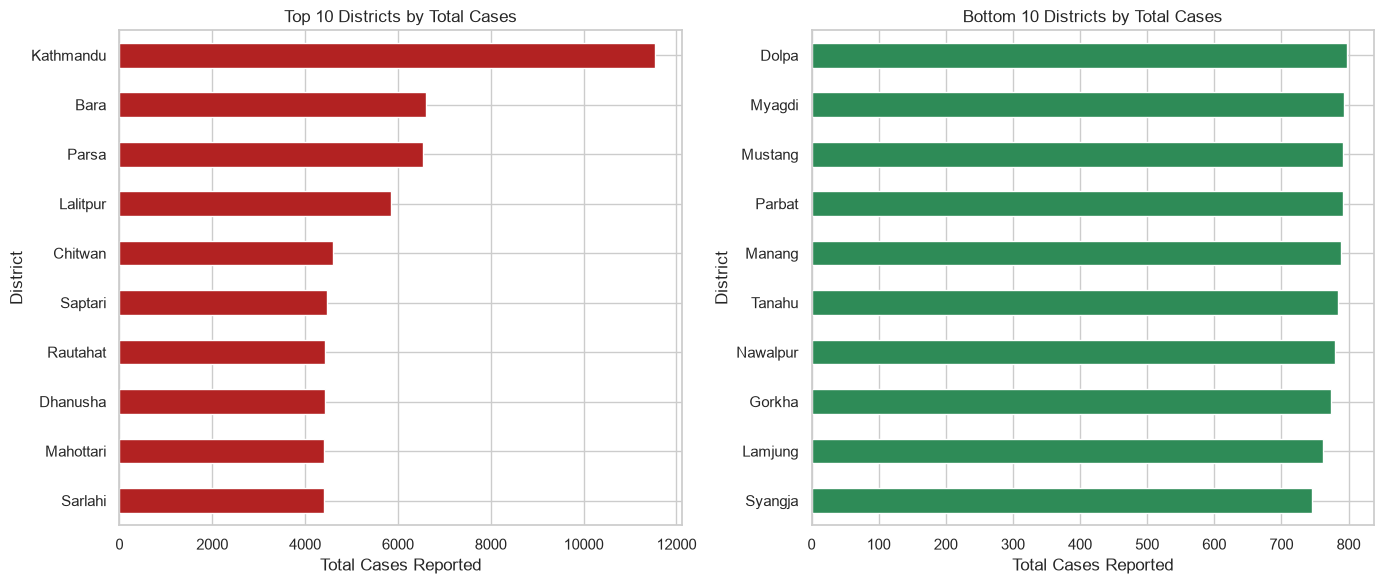

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

district_totals.head(10).plot(kind='barh', ax=axes[0], color='firebrick')
axes[0].set_title('Top 10 Districts by Total Cases')
axes[0].set_xlabel('Total Cases Reported')
axes[0].invert_yaxis()

district_totals.tail(10).sort_values().plot(kind='barh', ax=axes[1], color='seagreen')
axes[1].set_title('Bottom 10 Districts by Total Cases')
axes[1].set_xlabel('Total Cases Reported')

plt.tight_layout()
plt.savefig('../outputs/figures/district_top_bottom.png', dpi=150)
plt.show()

In [21]:
province_category = df[df['Year'] != 2026].pivot_table(
    index = 'Province',
    columns = 'Crime_Category',
    values = 'Cases_Reported',
    aggfunc = 'sum'
)

province_category_pct = province_category.div(province_category.sum(axis=1), axis=0) * 100

province_category_pct

Crime_Category,Attempt to Rape,Child Marriage,Child Sexual Abuse,Cybercrime,Domestic Violence,Human Trafficking,Physical Abuse,Rape,Sexual Harassment
Province,,,,,,,,,
Bagmati,1.838348,0.174624,0.970986,31.942739,51.425775,0.602548,4.066242,7.936752,1.041986
Gandaki,3.979069,0.970239,2.616374,5.668811,63.348959,1.133762,5.080126,14.226534,2.976126
Karnali,3.031716,1.096082,1.760728,2.425373,68.528451,1.037780,5.970149,13.980877,2.168843
Koshi,4.776624,0.513239,2.128776,8.410125,56.660446,0.711536,4.636650,19.648898,2.513706
Lumbini,2.688432,0.370818,1.378476,2.555421,73.591294,1.072148,5.836356,10.902862,1.604192
Madhesh,1.120194,0.201837,0.933495,1.892219,82.937229,0.206883,6.751438,4.813806,1.142900
Sudurpashchim,3.685609,0.728551,1.937088,2.811348,69.726579,0.779978,5.579841,12.453930,2.297077


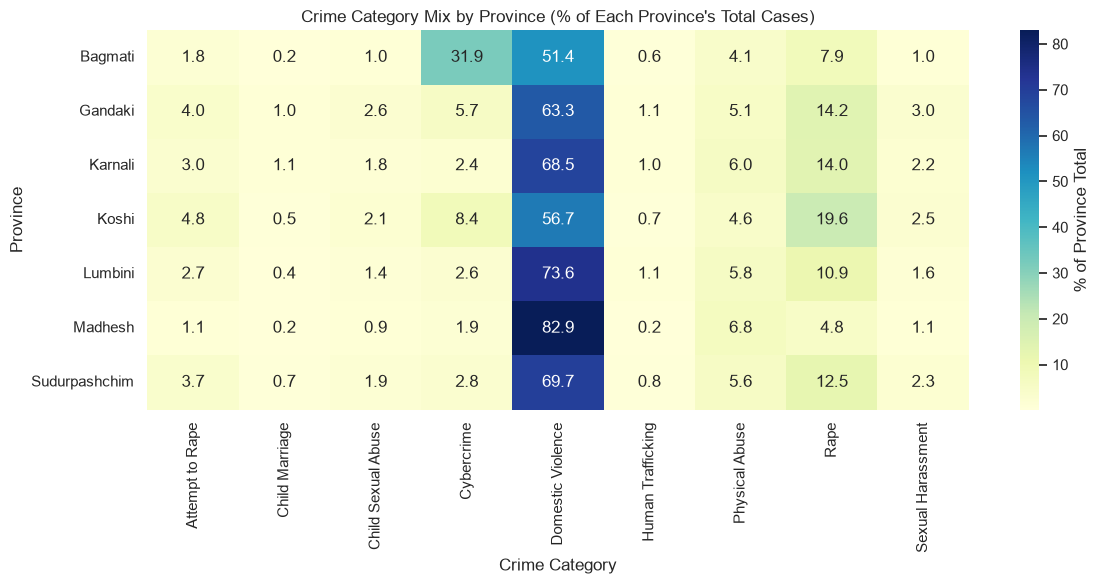

In [22]:
plt.figure(figsize=(12, 6))
sns.heatmap(province_category_pct, cmap='YlGnBu', annot=True, fmt='.1f', cbar_kws={'label': '% of Province Total'})
plt.title('Crime Category Mix by Province (% of Each Province\'s Total Cases)')
plt.xlabel('Crime Category')
plt.ylabel('Province')
plt.tight_layout()
plt.savefig('../outputs/figures/province_category_mix.png', dpi=150)
plt.show()

In [23]:
station_totals = df[df['Year'] != 2026].groupby('Police_Station')['Cases_Reported'].sum().sort_values(ascending=False)

print("Top 10 police stations by total cases:")
print(station_totals.head(10))
print()
print("Summary stats across all stations:")
print(station_totals.describe())

Top 10 police stations by total cases:
Police_Station
WCSC Birgunj      3839
WCSC Gaur         3529
Bara Sadar PS     2564
WCSC Bhaktapur    2449
Jaleshwar PS      2420
WCSC Thamel       2390
Parsa Sadar PS    2388
WCSC Patan        2316
Pokhariya PS      2174
Kalaiya PS        2172
Name: Cases_Reported, dtype: int64

Summary stats across all stations:
count     178.000000
mean      916.404494
std       611.924993
min       237.000000
25%       480.500000
50%       665.500000
75%      1237.250000
max      3839.000000
Name: Cases_Reported, dtype: float64


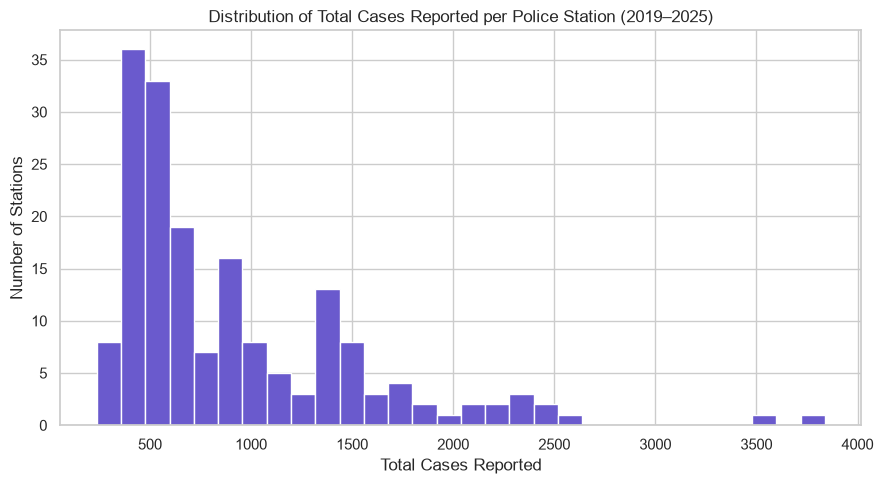

In [24]:
plt.figure(figsize=(9, 5))
plt.hist(station_totals.values, bins=30, color='slateblue', edgecolor='white')
plt.title('Distribution of Total Cases Reported per Police Station (2019–2025)')
plt.xlabel('Total Cases Reported')
plt.ylabel('Number of Stations')
plt.tight_layout()
plt.savefig('../outputs/figures/station_distribution.png', dpi=150)
plt.show()

### Section 3 Takeaways

- **Province totals:** Bagmati (~52,000) and Madhesh (~39,500) report far mroe cases than any other provinces; Karnali and Gandaki are lowest (~8,500-9,500). Since Bagmati includes Kathmandu (Nepal's most populous area), this likely refelcts population size as much as incidence rate - per capita analysis with external population data would be needed to say more.

- **District extremes:** Kathmandu is a major outleir (~11,500 cases), well above the next-highest district. The lowest-case districts are almost all mountainous/rural (Dolpa, Myagdi, Mustang, Manang), which may reflect lower population density or even lower reporting despite the existence of the crimes.

- **Crime mix by province:** Cybercrime makes up 31.9% of Bagmati's total cases vs just 1.9-8.4% in every other province. This strongly suggests concentration in more urban/connected areas. Correspondingly, Domestic violence makes up a relatively smaller share of Bagmati's mix (51.4%) than elsewhere (even though it is still Bagmati's largest category by far.) Madhesh shows the most concentrated mix with Domestic Violence at 82.9% of its total cases - worth further investigation as to why. Koshi stands out for its comparatively high Rape share (19.6%) relative to other provinces.

- **Police station spread:** Case volume per station is right-skewed - most
  stations report 300-1,000 total cases, with a small number of high-volume
  outliers (likely concentrated in Bagmati/Kathmandu) reporting 3,500+.

## Section 4: Crime Category Breakdown

Note: 2026 excluded from totals below (partial year).

In [27]:
category_totals = df[df['Year'] != 2026].groupby('Crime_Category')['Cases_Reported'].sum().sort_values(ascending=False)
category_totals

Crime_Category
Domestic Violence     107468
Cybercrime             20528
Rape                   16075
Physical Abuse          8667
Attempt to Rape         3943
Sexual Harassment       2552
Child Sexual Abuse      2200
Human Trafficking       1068
Child Marriage           619
Name: Cases_Reported, dtype: int64

/var/folders/lt/v71y3chd6vngt4xqc0gq5sy80000gn/T/ipykernel_78117/3058247638.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=category_pct.values, y=category_pct.index, palette='Set2')


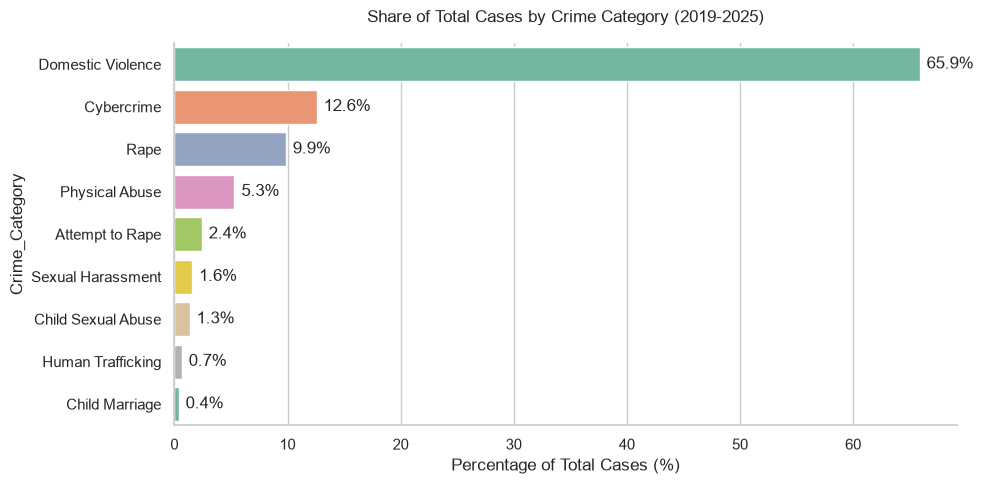

In [39]:
category_pct = (category_totals / category_totals.sum()) * 100

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=category_pct.values, y=category_pct.index, palette='Set2')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=5)

plt.title('Share of Total Cases by Crime Category (2019-2025)', pad=15)
plt.xlabel('Percentage of Total Cases (%)')
sns.despine()
plt.tight_layout()
plt.show()